# Medical Advice Chatbot
LLM, Hugging Face native format (safetensors)

## Warning!

This example uses a model trained on Llama3.2-1B. To run this notebook, you will have to have a Hugging Face token and
agree to the proprietary license on the [model page](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct).

## Dependencies and Preparation

Install dependencies

In [1]:
%pip -q install requests matplotlib numpy "torch==2.10.0" torchvision "transformers~=4.53.3" sentence-transformers "peft==0.18.1" "bitsandbytes>=0.46.1"

Note: you may need to restart the kernel to use updated packages.


Download checkpoints and sample data

In [2]:
import io
import zipfile
from pathlib import Path

import requests

ZIPFILE_NAME = "HF_MedicalChatbot"
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / ZIPFILE_NAME
ZIP_URL = f"https://github.com/Authentrics-ai/authentrics-analysis-example-models/raw/refs/heads/main/{ZIPFILE_NAME}.zip"

if DATA_PATH.exists():
    print(f"Data already exists in {DATA_PATH}")

else:
    print(f"Downloading data from {ZIP_URL}...")
    response = requests.get(ZIP_URL)
    if response.status_code != 200:
        raise Exception(f"Failed to download file: {response.text}")

    print("Extracting the zip file...")
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(DATA_DIR)

    if not DATA_PATH.is_dir():
        raise Exception(f"Failed to extract data: {DATA_PATH}")

    print(f"Data extracted to {DATA_PATH}")


Extracting the zip file...
Data extracted to data/HF_MedicalChatbot


## Implement `ModelInterface`

In [3]:
from pathlib import Path
from typing import Any, Callable, Optional

import torch
from peft import PeftConfig
from transformers.models.auto import AutoConfig
from transformers.pipelines import pipeline
from transformers.pipelines.text_generation import TextGenerationPipeline

from authentrics import (
    InferenceResult,
    ModelInterface,
    TensorDict,
)

Handle = torch.utils.hooks.RemovableHandle
Hook = Callable[[torch.nn.Module, object, object], None]


def _make_capture_hook(layer_name: str, storage: TensorDict) -> Hook:
    """Return a forward hook that stores this layer's output in storage (torch, CPU)."""

    def hook(
        _module: torch.nn.Module, _input: object, output: torch.Tensor | tuple
    ) -> None:
        out = output[0] if isinstance(output, tuple) else output
        storage[layer_name] = out.detach().clone()

    return hook


def _register_per_layer_output_hooks(
    model: TextGenerationPipeline,
    storage: TensorDict,
    layer_names: list[str] | None = None,
) -> list[Handle]:
    """Register forward hooks on the given layers; capture outputs into storage.
    Returns handle list for removal.
    """
    layer_modules = {
        name: mod
        for name, mod in model.model.named_modules()
        if name != "" and name in layer_names
    }
    handles: list[Handle] = []
    for name, module in layer_modules.items():
        if hasattr(module, "register_forward_hook"):
            h: Handle = module.register_forward_hook(_make_capture_hook(name, storage))
            handles.append(h)
    return handles


class SimpleHFModel(ModelInterface):
    def __init__(
        self, inference_config: dict[str, Any] | None = None, batch_size: int = 1
    ):
        super().__init__()
        self._module = None
        self._inference_config = inference_config
        self._batch_size = batch_size

    def load(self, checkpoint_path: Path | str | bytes) -> None:
        config_filepaths = list(checkpoint_path.rglob("*config.json"))
        model_path = config_filepaths[0].parent

        try:
            peft_config = PeftConfig.from_pretrained(str(model_path))
            config = AutoConfig.from_pretrained(peft_config.base_model_name_or_path)
        except Exception:
            config = AutoConfig.from_pretrained(str(model_path))

        if hasattr(config, "torch_dtype"):
            torch_dtype = config.torch_dtype
        else:
            torch_dtype = None

        self._module: TextGenerationPipeline = pipeline(
            "text-generation",
            model=str(model_path),
            device_map="sequential",
            trust_remote_code=True,
            torch_dtype=torch_dtype,
        )

    def get_parameters(
        self,
        parameter_names: Optional[list[str]] = None,
    ) -> TensorDict:
        parameters = TensorDict()
        for name, param in self._module.model.named_parameters():
            if parameter_names is None or name in parameter_names:
                parameters[name] = param.detach().clone()

        return parameters

    def perform_inference(
        self,
        input_data: list[str],
        return_intermediate_outputs: bool = False,
        layer_names: Optional[list[str]] = None,
    ) -> InferenceResult:

        intermediate_outputs = TensorDict()
        handles: list[Handle] = []
        if return_intermediate_outputs:
            handles = _register_per_layer_output_hooks(
                self._module, intermediate_outputs, layer_names=layer_names
            )

        max_new_tokens = int(self._inference_config.pop("max_new_tokens", 50))

        try:
            result = self._module(
                text_inputs=input_data,
                max_new_tokens=max_new_tokens,
                batch_size=self._batch_size,
            )
        finally:
            for h in handles:
                h.remove()

        return InferenceResult(
            output=result,
            intermediate_outputs=intermediate_outputs,
        )

    def set_parameters(self, parameters: TensorDict) -> None:
        state = {n: p for n, p in self._module.model.named_parameters()}
        for name, tensor in parameters.items():
            if name in state:
                state[name].data.copy_(tensor)

    def save(self, checkpoint_path: Path | str | bytes) -> None:
        path = Path(checkpoint_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        self._module.save_pretrained(path)


In [4]:
from authentrics import AuthentricsSession, use_backend

use_backend("torch")

model = SimpleHFModel(inference_config={"max_new_tokens": 100}, batch_size=8)
session = AuthentricsSession(model)

project = session.get_or_create_project(
    "MedicalChatbotExample",
    "Example project for Hugging Face-based LLM",
)

checkpoint_paths = [DATA_PATH / f"iteration_{i}" for i in range(4)]
assert all(path.is_dir() for path in checkpoint_paths), "All checkpoint directories must exist!"

checkpoint_paths

[PosixPath('data/HF_MedicalChatbot/iteration_0'),
 PosixPath('data/HF_MedicalChatbot/iteration_1'),
 PosixPath('data/HF_MedicalChatbot/iteration_2'),
 PosixPath('data/HF_MedicalChatbot/iteration_3')]

## Static Analysis

In [5]:
result = session.static_analysis(
    project.id,
    checkpoint_paths[0],
    checkpoint_paths[1],
    parameter_names=[
        "model.layers.0.mlp.down_proj.lora_A.default.weight",
        "model.layers.0.mlp.down_proj.lora_B.default.weight",
        "model.layers.0.self_attn.q_proj.lora_A.default.weight",
        "model.layers.0.self_attn.q_proj.lora_B.default.weight",
        "model.layers.8.mlp.down_proj.lora_A.default.weight",
        "model.layers.8.mlp.down_proj.lora_B.default.weight",
        "model.layers.8.self_attn.q_proj.lora_A.default.weight",
        "model.layers.8.self_attn.q_proj.lora_B.default.weight",
        "model.layers.15.mlp.down_proj.lora_A.default.weight",
        "model.layers.15.mlp.down_proj.lora_B.default.weight",
        "model.layers.15.self_attn.q_proj.lora_A.default.weight",
        "model.layers.15.self_attn.q_proj.lora_B.default.weight",
    ],
)

result

Device set to use cuda:0
Device set to use cuda:0


<StaticAnalysisResult object num_params=12, summary_score=0.00051675923>

In [6]:
print(result.to_dataframe())

                                                    parameter_changes
model.layers.0.mlp.down_proj.lora_A.default.weight           0.000515
model.layers.0.mlp.down_proj.lora_B.default.weight           0.000498
model.layers.0.self_attn.q_proj.lora_A.default....           0.000527
model.layers.0.self_attn.q_proj.lora_B.default....           0.000506
model.layers.15.mlp.down_proj.lora_A.default.we...           0.000494
model.layers.15.mlp.down_proj.lora_B.default.we...           0.000494
model.layers.15.self_attn.q_proj.lora_A.default...           0.000559
model.layers.15.self_attn.q_proj.lora_B.default...           0.000585
model.layers.8.mlp.down_proj.lora_A.default.weight           0.000520
model.layers.8.mlp.down_proj.lora_B.default.weight           0.000513
model.layers.8.self_attn.q_proj.lora_A.default....           0.000533
model.layers.8.self_attn.q_proj.lora_B.default....           0.000522


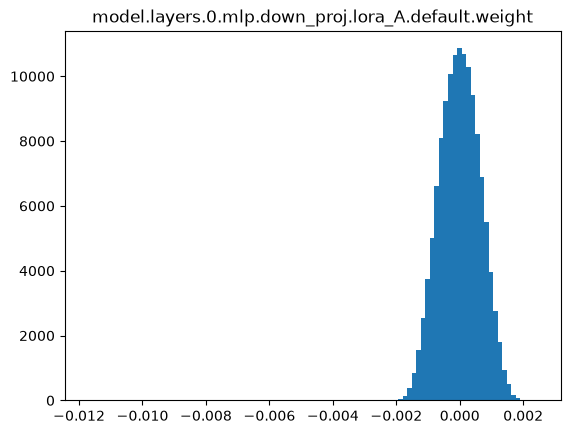

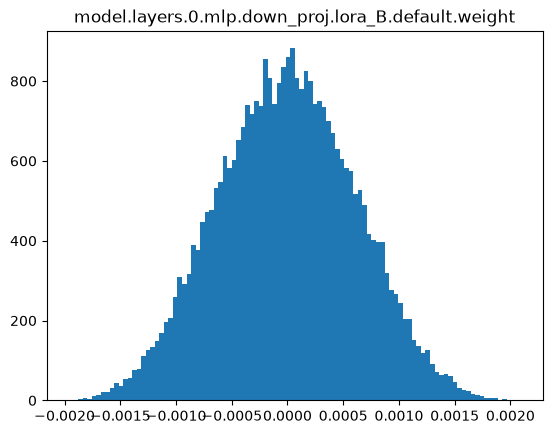

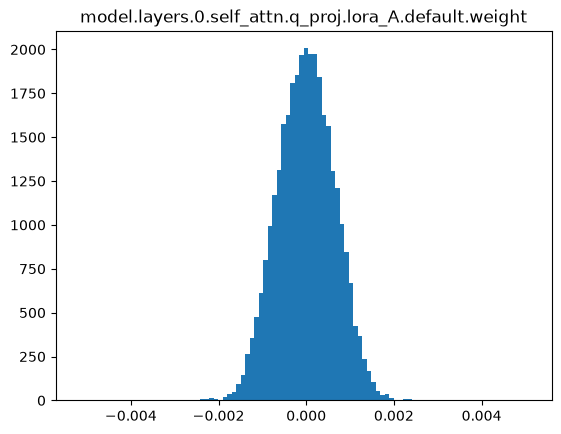

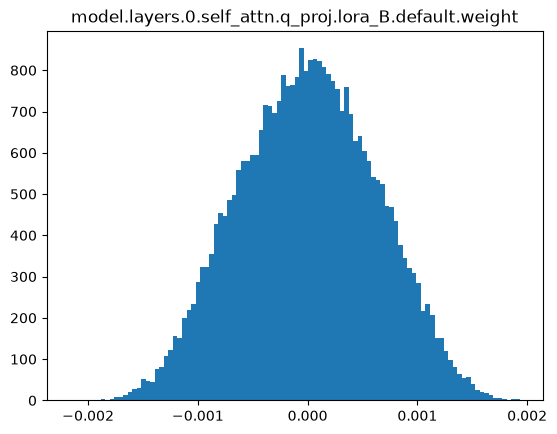

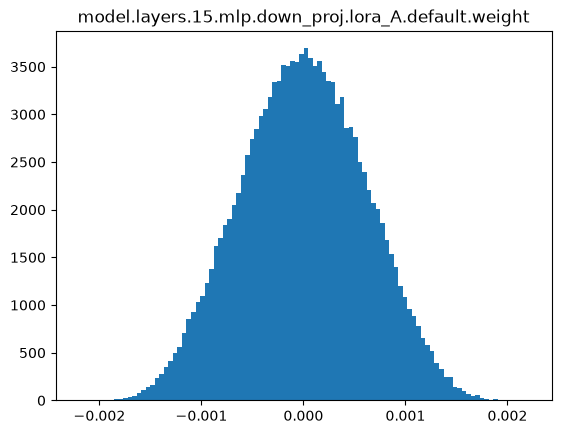

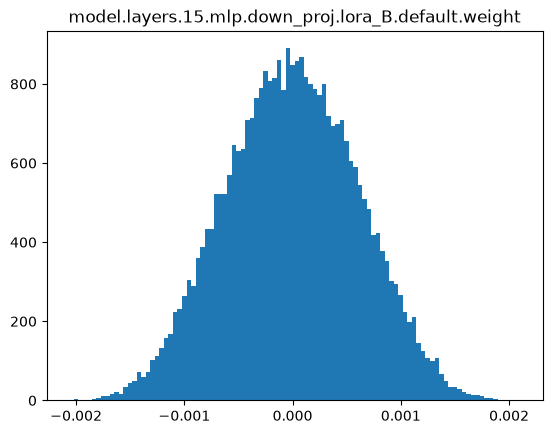

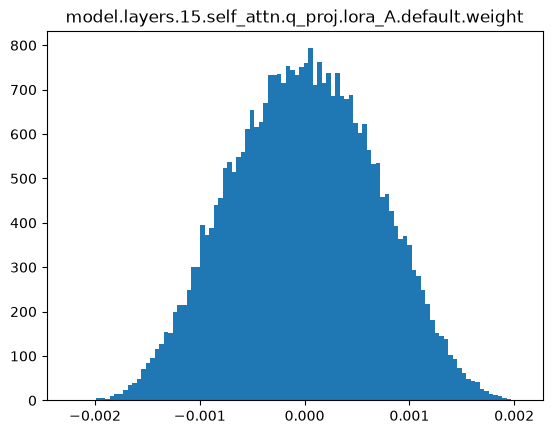

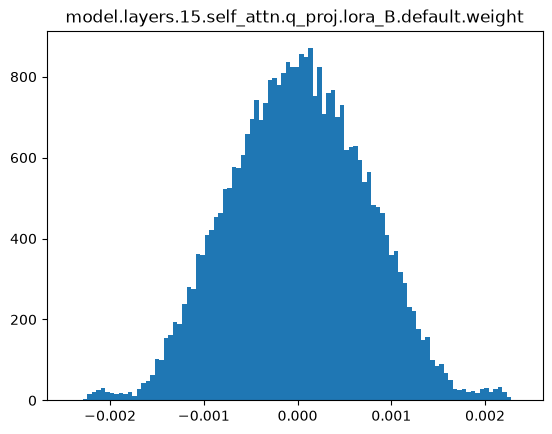

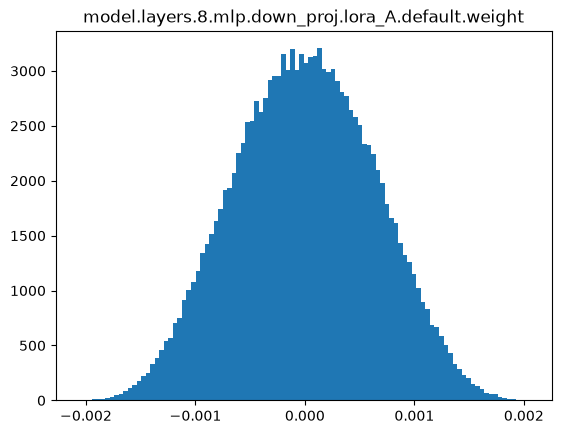

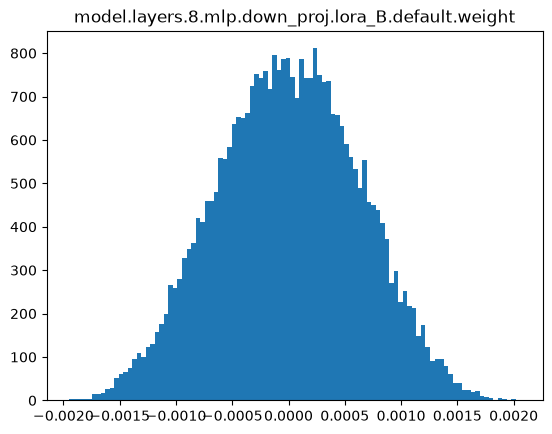

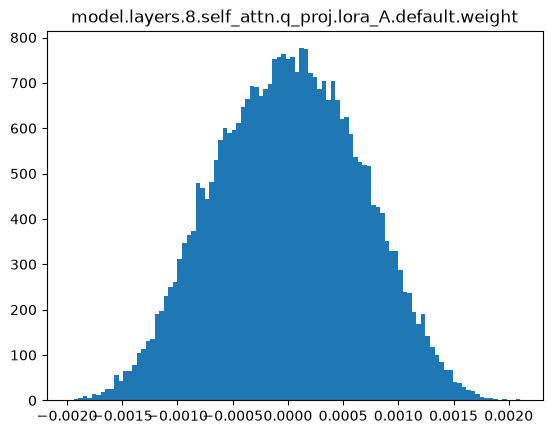

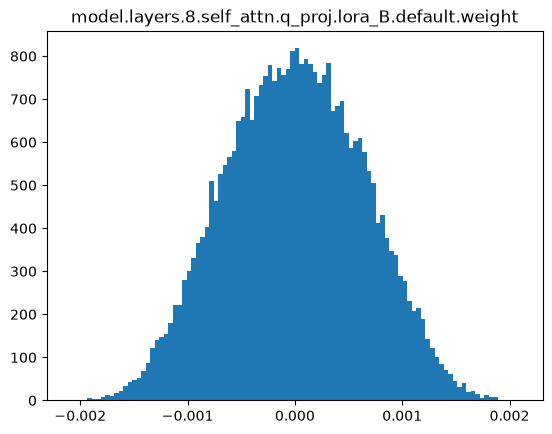

In [7]:
import matplotlib.pyplot as plt
import numpy as np

for i, (param, hist) in enumerate(zip(result.parameter_names, result.parameter_histograms)):
    plt.figure(i)
    plt.hist((np.array(hist.bin_edges[1:]) + np.array(hist.bin_edges[:-1])) / 2, weights=hist.bin_counts, bins=hist.bin_edges)
    plt.title(param)

## Activation Analysis

In [8]:
import json

stimfile = DATA_PATH / "stimuli.jsonl"
with open(stimfile, "r") as f:
    stimuli = [json.loads(line) for line in f]

print(stimuli)

[[{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'What should I do if I miss a dose of my medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Is it normal to feel tired all the time after starting a new medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'How can I lower my blood pressure naturally?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'When should I see a doctor for a persistent cough?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Are there side effects to getting the flu vaccine?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Can I take ibuprofen if I have stomach ulcers?'}], [{'role': 'system', 'content': 'You ar

In [9]:
result = session.activation_analysis(
    project.id,
    checkpoint_paths[0],
    checkpoint_paths[1],
    stimuli,
    layer_names=[
        "model.layers.0.mlp.down_proj",
        "model.layers.0.self_attn.q_proj",
        "model.layers.8.mlp.down_proj",
        "model.layers.8.self_attn.q_proj",
        "model.layers.15.mlp.down_proj",
        "model.layers.15.self_attn.q_proj",
    ],
)

Device set to use cuda:0
Device set to use cuda:0


In [10]:
print(result.to_dataframe())


                                  cosine_similarities  l2_distances
model.layers.0.mlp.down_proj                 0.193359      1.557845
model.layers.0.self_attn.q_proj              0.917969     33.764351
model.layers.15.mlp.down_proj                0.562500     16.086679
model.layers.15.self_attn.q_proj             0.878906     39.597980
model.layers.8.mlp.down_proj                 0.187500      4.772971
model.layers.8.self_attn.q_proj              0.835938     36.769554


## Correlation Analysis

In [11]:
import json

stimfile = DATA_PATH / "stimuli.jsonl"
with open(stimfile, "r") as f:
    stimuli = [json.loads(line) for line in f]

print(stimuli)

[[{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'What should I do if I miss a dose of my medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Is it normal to feel tired all the time after starting a new medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'How can I lower my blood pressure naturally?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'When should I see a doctor for a persistent cough?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Are there side effects to getting the flu vaccine?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Can I take ibuprofen if I have stomach ulcers?'}], [{'role': 'system', 'content': 'You ar

In [12]:
result = session.correlation_analysis(
    project.id,
    checkpoint_paths[1],
    stimuli,
    layer_names=[
        "model.layers.0.mlp.down_proj",
        "model.layers.0.self_attn.q_proj",
        "model.layers.8.mlp.down_proj",
        "model.layers.8.self_attn.q_proj",
        "model.layers.15.mlp.down_proj",
        "model.layers.15.self_attn.q_proj",
    ],
    reference_layer_name="model.norm",
)

Device set to use cuda:0


In [13]:
print(result.to_dataframe())

                                  correlation_scores
model.layers.0.mlp.down_proj                0.380173
model.layers.0.self_attn.q_proj             0.377595
model.layers.15.mlp.down_proj               0.391561
model.layers.15.self_attn.q_proj            0.389059
model.layers.8.mlp.down_proj                0.381455
model.layers.8.self_attn.q_proj             0.387802


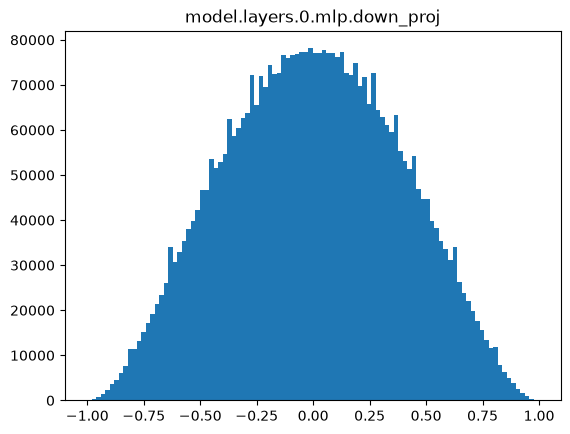

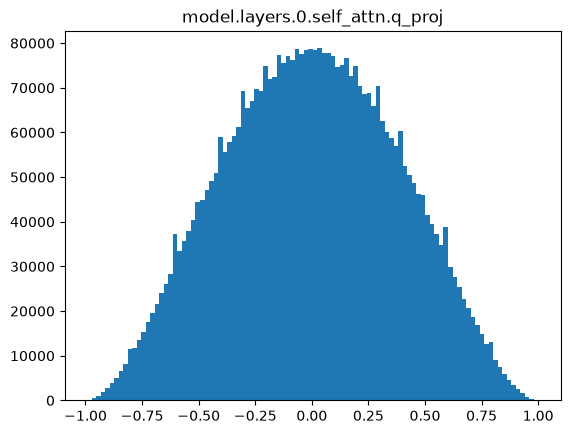

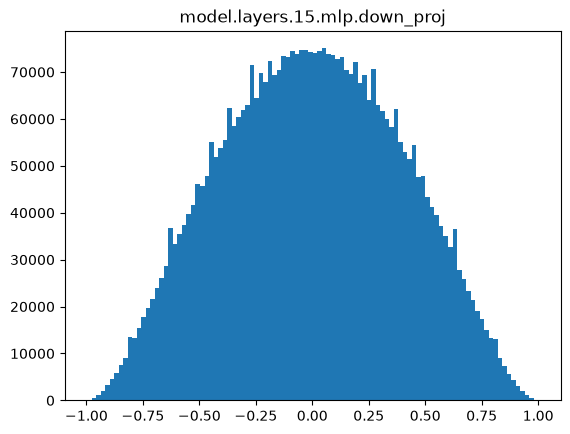

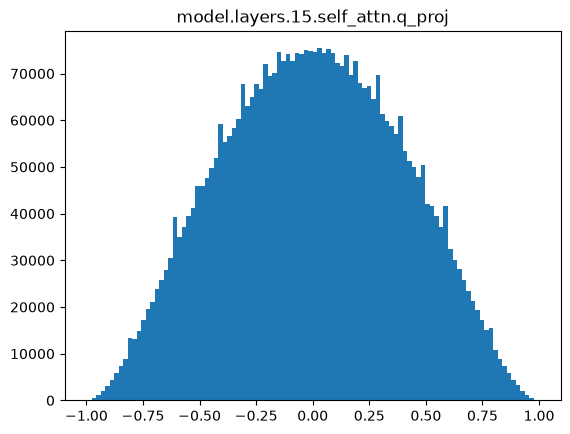

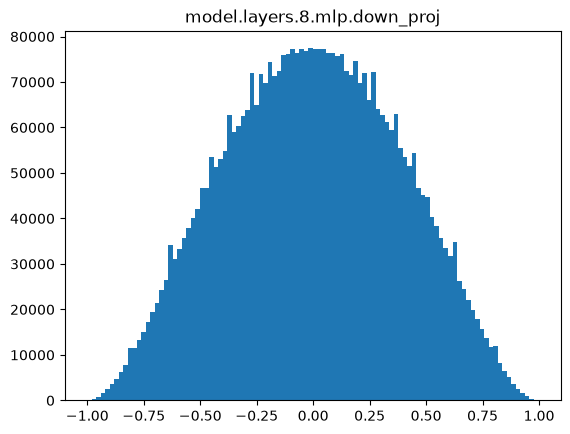

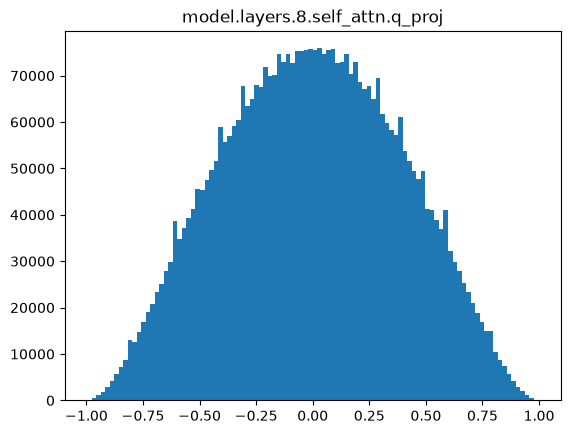

In [14]:
import matplotlib.pyplot as plt
import numpy as np

for i, (param, hist) in enumerate(zip(result.layer_names, result.correlation_histograms)):
    plt.figure(i)
    plt.hist((np.array(hist.bin_edges[1:]) + np.array(hist.bin_edges[:-1])) / 2, weights=hist.bin_counts, bins=hist.bin_edges)
    plt.title(param)

## Exclude Training

In [15]:
session.exclude_training(
    project.id,
    checkpoint_paths,
    [2],
    DATA_PATH / "excluded_2",
)

Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


data/HF_MedicalChatbot/excluded_2

In [16]:
(DATA_PATH / "excluded_2").is_dir()

True

## Zero-Training Optimization & Maintenance (ZTOM)

In [17]:
from sentence_transformers import SentenceTransformer

def sentence_similarity_loss_fn(
    expected_output: list[str],
    output: list[list[dict[str, str]]],
) -> float:
    similarity_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    generated_embeddings = similarity_model.encode(
        [o[0]["generated_text"][-1]["content"] for o in output]
    )
    expected_embeddings = similarity_model.encode(expected_output)
    score = (
        similarity_model.similarity_pairwise(generated_embeddings, expected_embeddings)
        .mean()
        .item()
    )
    return score

In [18]:
import json

stimfile = DATA_PATH / "stimuli.jsonl"
with open(stimfile, "r") as f:
    stimuli = [json.loads(line) for line in f]

print(stimuli)

[[{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'What should I do if I miss a dose of my medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Is it normal to feel tired all the time after starting a new medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'How can I lower my blood pressure naturally?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'When should I see a doctor for a persistent cough?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Are there side effects to getting the flu vaccine?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Can I take ibuprofen if I have stomach ulcers?'}], [{'role': 'system', 'content': 'You ar

In [19]:
with open(DATA_PATH / "expected_outputs.txt", "r") as f:
    expected_output = [line.strip() for line in f]

expected_output

['If you miss a dose, you should take the missed dose as soon as possible. You should not wait until the next scheduled dose. If you are missing doses regularly, your doctor will tell you to take them regularly. If you have missed one dose, you should take another one as soon as possible. You should not take any extra dose.',
 'I went through your query and can understand your concern.  Yes, it is normal to feel tired all the time after starting a new medication. The new medication can cause fatigue, which is a common side effect of many drugs. This fatigue is usually temporary and resolves on its own within a few days. If you are still feeling tired, it is best to consult your doctor and discuss with them about your medication. They can help you identify the cause of your fatigue and suggest the appropriate treatment. In',
 'I can understand your concern.  There are many ways to lower blood pressure naturally. Here are some of the ways:  1. Exercise regularly. Regular exercise can hel

In [20]:
from authentrics import ZtomOptimizationOptions

# Optional: tune optimization (defaults are often sufficient)
# In this case, we want to maximize the similarity between the generated and expected outputs.
options = ZtomOptimizationOptions(minimize=False)

# loss_function: callable(model_output) -> float
# can be passed directly as a lambda or normal function
result = session.ztom_analysis(
    project.id,
    checkpoint_paths,
    stimuli,
    loss_function=lambda y_pred: sentence_similarity_loss_fn(expected_output, y_pred),
    new_checkpoint_path=DATA_PATH / "checkpoint_optimized",
    optimization_options=options,
)

Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [21]:
print(result.scaling_factors)
print(result.number_of_inferences)

[0.06602873860456082, 1.1041272506578192, 0.22664785586096764]
47
